# Introduzione a scikit-learn

**scikit-learn** è la libreria Python più usata per il machine learning classico. Offre strumenti semplici ed efficienti per:
- classificazione, regressione, clustering
- preprocessing dei dati
- valutazione dei modelli

In questo notebook vediamo un esempio completo end-to-end.

## 1. Importazioni

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

print('Librerie importate con successo!')

Librerie importate con successo!


## 2. Dataset: Iris

Il dataset **Iris** è un classico benchmark: 150 campioni di fiori divisi in 3 specie, con 4 feature (lunghezza e larghezza di sepalo e petalo).

In [2]:
# Carichiamo il dataset
iris = datasets.load_iris()
X = iris.data          # feature: (150, 4)
y = iris.target        # etichette: 0, 1, 2

print('Shape X:', X.shape)
print('Classi:', iris.target_names)
print('Feature:', iris.feature_names)

Shape X: (150, 4)
Classi: ['setosa' 'versicolor' 'virginica']
Feature: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# Visualizziamo le prime righe
import pandas as pd
df = pd.DataFrame(X, columns=iris.feature_names)
df['specie'] = [iris.target_names[i] for i in y] # aggiungiamo una colonna con i nomi delle specie per rendere più leggibile il dataset
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),specie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


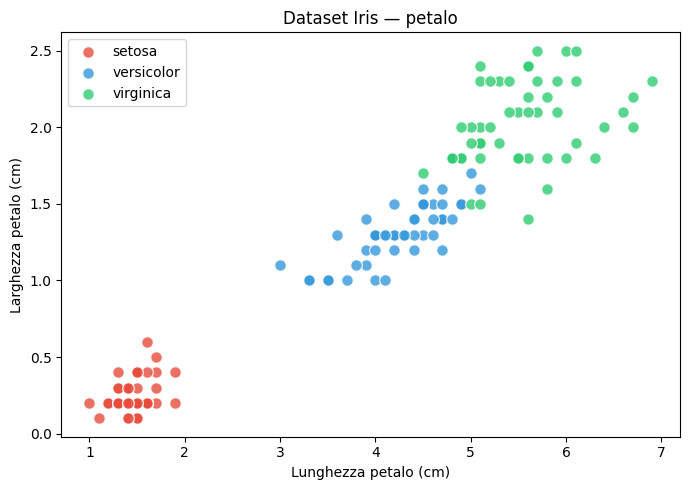

In [ ]:
# Scatter plot: lunghezza petalo vs larghezza petalo
colors = ['#e74c3c', '#3498db', '#2ecc71']
fig, ax = plt.subplots(figsize=(7, 5))

for i, specie in enumerate(iris.target_names):
    mask = y == i
    ax.scatter(X[mask, 2], X[mask, 3], label=specie, #prendiamo solo le colonne 2 e 3 (lunghezza e larghezza petalo)
               color=colors[i], alpha=0.8, edgecolors='white', s=70)

ax.set_xlabel('Lunghezza petalo (cm)')
ax.set_ylabel('Larghezza petalo (cm)')
ax.set_title('Dataset Iris — petalo')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Preprocessing

Prima di addestrare un modello, dobbiamo:
1. **Dividere** i dati in train e test
2. **Normalizzare** le feature (importante per alcuni algoritmi)

In [5]:
# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} campioni')
print(f'Test:  {X_test.shape[0]} campioni')

Train: 120 campioni
Test:  30 campioni


In [6]:
# Standardizzazione: media 0, deviazione standard 1
# IMPORTANTE: fit solo su train, poi transform anche su test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Media (prima):', X_train[:, 0].mean().round(2))
print('Media (dopo): ', X_train_sc[:, 0].mean().round(4))

Media (prima): 5.84
Media (dopo):  -0.0


## 4. API unificata di scikit-learn

Il punto di forza di scikit-learn è l'**API consistente** per tutti i modelli:

```python
model = AlgoritmoScelto(parametri...)
model.fit(X_train, y_train)       # addestramento
y_pred = model.predict(X_test)    # predizione
```

Vediamo tre algoritmi di classificazione.

### 4a. K-Nearest Neighbors (KNN)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)
print('Accuratezza KNN:', accuracy_score(y_test, y_pred_knn))

Accuratezza KNN: 0.9333333333333333


### 4b. Regressione Logistica

In [10]:
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
print('Accuratezza Logistic Regression:', accuracy_score(y_test, y_pred_lr))

Accuratezza Logistic Regression: 0.9333333333333333


### 4c. Albero Decisionale

In [27]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt.fit(X_train, y_train)   # alberi non richiedono scaling

y_pred_dt = dt.predict(X_test)
print('Accuratezza Decision Tree:', accuracy_score(y_test, y_pred_dt))

Accuratezza Decision Tree: 0.9666666666666667


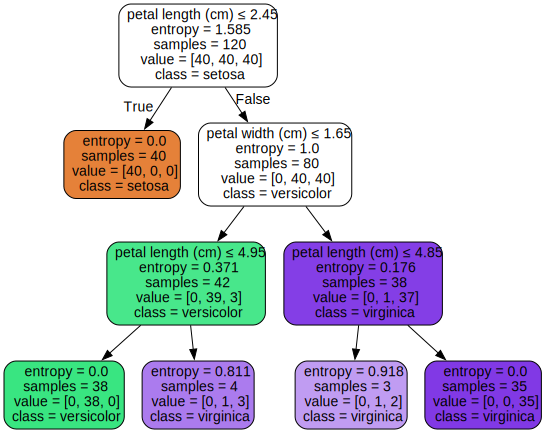

In [28]:
from sklearn import tree
import graphviz
dot_data = tree.export_graphviz(dt, out_file=None,
                        feature_names=iris.feature_names,
                        class_names=iris.target_names,
                        filled=True, rounded=True,
                        special_characters=True)
graph = graphviz.Source(dot_data) #si può visualizzare anche con plot tree
graph

## 5. Valutazione dei modelli

Oltre all'accuratezza, usiamo report e matrice di confusione.

In [12]:
# Report dettagliato per la Regressione Logistica
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



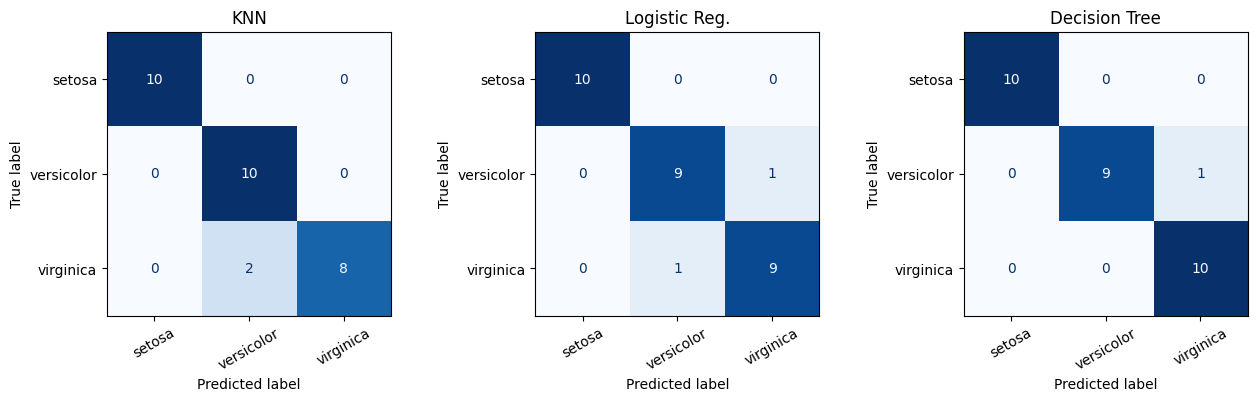

In [13]:
# Matrice di confusione
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, y_pred) in zip(axes, [
    ('KNN', y_pred_knn),
    ('Logistic Reg.', y_pred_lr),
    ('Decision Tree', y_pred_dt)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=iris.target_names,
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

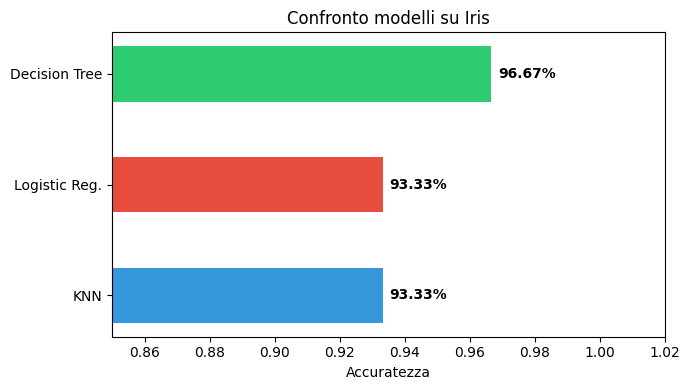

In [14]:
# Confronto visivo delle accuratezze
modelli = ['KNN', 'Logistic Reg.', 'Decision Tree']
acc = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt)
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(modelli, acc, color=['#3498db', '#e74c3c', '#2ecc71'], height=0.5)
ax.set_xlim(0.85, 1.02)
ax.set_xlabel('Accuratezza')
ax.set_title('Confronto modelli su Iris')

for bar, a in zip(bars, acc):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{a:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Pipeline: un oggetto che fa tutto

scikit-learn permette di incapsulare preprocessing + modello in una **Pipeline**, così non rischiamo mai il data leakage.

In [15]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier(n_neighbors=5))
])

# Si usa esattamente come un modello normale
pipe.fit(X_train, y_train)
print('Accuratezza Pipeline:', accuracy_score(y_test, pipe.predict(X_test)))

Accuratezza Pipeline: 0.9333333333333333


## 7. Cross-validation

Per una stima più robusta delle performance, usiamo la **k-fold cross-validation**.

In [16]:
from sklearn.model_selection import cross_val_score

# 5-fold CV sulla Pipeline intera (nessun data leakage!)
scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

print(f'Accuratezze per fold: {scores.round(3)}')
print(f'Media: {scores.mean():.3f}  ±  {scores.std():.3f}')

Accuratezze per fold: [0.967 0.967 0.933 0.933 1.   ]
Media: 0.960  ±  0.025


## Riepilogo

| Concetto | Funzione/Classe |
|---|---|
| Caricare dataset | `datasets.load_iris()` |
| Dividere dati | `train_test_split()` |
| Normalizzare | `StandardScaler` |
| Addestrare | `model.fit(X_train, y_train)` |
| Predire | `model.predict(X_test)` |
| Valutare | `accuracy_score`, `classification_report` |
| Pipeline | `Pipeline([...])` |
| Cross-validation | `cross_val_score()` |

---
**Prossimi passi:** prova a sostituire il dataset Iris con i tuoi dati, o esplora algoritmi come `RandomForestClassifier` o `SVC`.